Импорт всех необходимых библотек


In [1]:
import requests
import pandas as pd
from datetime import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
import seaborn as sns
import os
from dotenv import load_dotenv

Подготовка дат

In [2]:
load_dotenv()
API_URL = os.getenv("API_URL")
DATE_BEGIN = os.getenv("DATE_BEGIN")
DATE_END = os.getenv("DATE_END")

Импорт нужных данных

In [3]:
visits_response = requests.get(
    f"{API_URL}/visits", params={"begin": DATE_BEGIN, "end": DATE_END}
).json()
reg_response = requests.get(
    f"{API_URL}/registrations", params={"begin": DATE_BEGIN, "end": DATE_END}
).json()

Создание директории для графиков

In [4]:
os.makedirs("./charts", exist_ok=True)

Перевод всех данных в датафреймы

In [5]:
visits_df = pd.DataFrame(visits_response)
reg_df = pd.DataFrame(reg_response)
ads_df = pd.read_csv("./ads.csv")

Очистка визитов и регистраций

In [6]:
visits_df["datetime"] = pd.to_datetime(visits_df["datetime"])
reg_df["datetime"] = pd.to_datetime(reg_df["datetime"])
visits_df = visits_df[
    ~visits_df["user_agent"].str.contains("bot", case=False, na=False)
]
visits_df = visits_df.sort_values("datetime").drop_duplicates(
    subset="visit_id", keep="last"
)
visits_df["date_group"] = visits_df["datetime"].dt.date
reg_df["date_group"] = reg_df["datetime"].dt.date
agg_visits = (
    visits_df.groupby(["date_group", "platform"]).size().reset_index(name="visits")
)

agg_regs = (
    reg_df.groupby(["date_group", "platform"]).size().reset_index(name="registrations")
)

Расчет конверсии

In [7]:
df_result = pd.merge(
    agg_visits, agg_regs, on=["date_group", "platform"], how="outer"
).fillna(0)
df_result["conversion"] = (df_result["registrations"] / df_result["visits"]) * 100
df_result = df_result.sort_values(["date_group", "platform"]).reset_index(drop=True)
df_result.to_json("./conversion.json")

Групирровка по дате и рекламным кампаниям с расчетом суммы

In [8]:
ads_df["date"] = pd.to_datetime(ads_df["date"])
ads_df["group_date"] = ads_df["date"].dt.date
agg_ads = ads_df.groupby(["group_date", "utm_campaign"])["cost"].sum().reset_index()

Итоговый датасет с визитами, регистрациями, конверсией и затратами на рекламу

In [9]:
conv_ads_df = pd.merge(
    df_result, agg_ads, left_on=["date_group"], right_on=["group_date"], how="left"
).fillna({"cost": 0, "utm_campaign": "none"})
conv_ads_df = conv_ads_df.drop(columns=["group_date"])
conv_ads_df = conv_ads_df.sort_values("date_group").reset_index(drop=True)
conv_ads_df.to_json("./ads.json")

Итоговые визиты

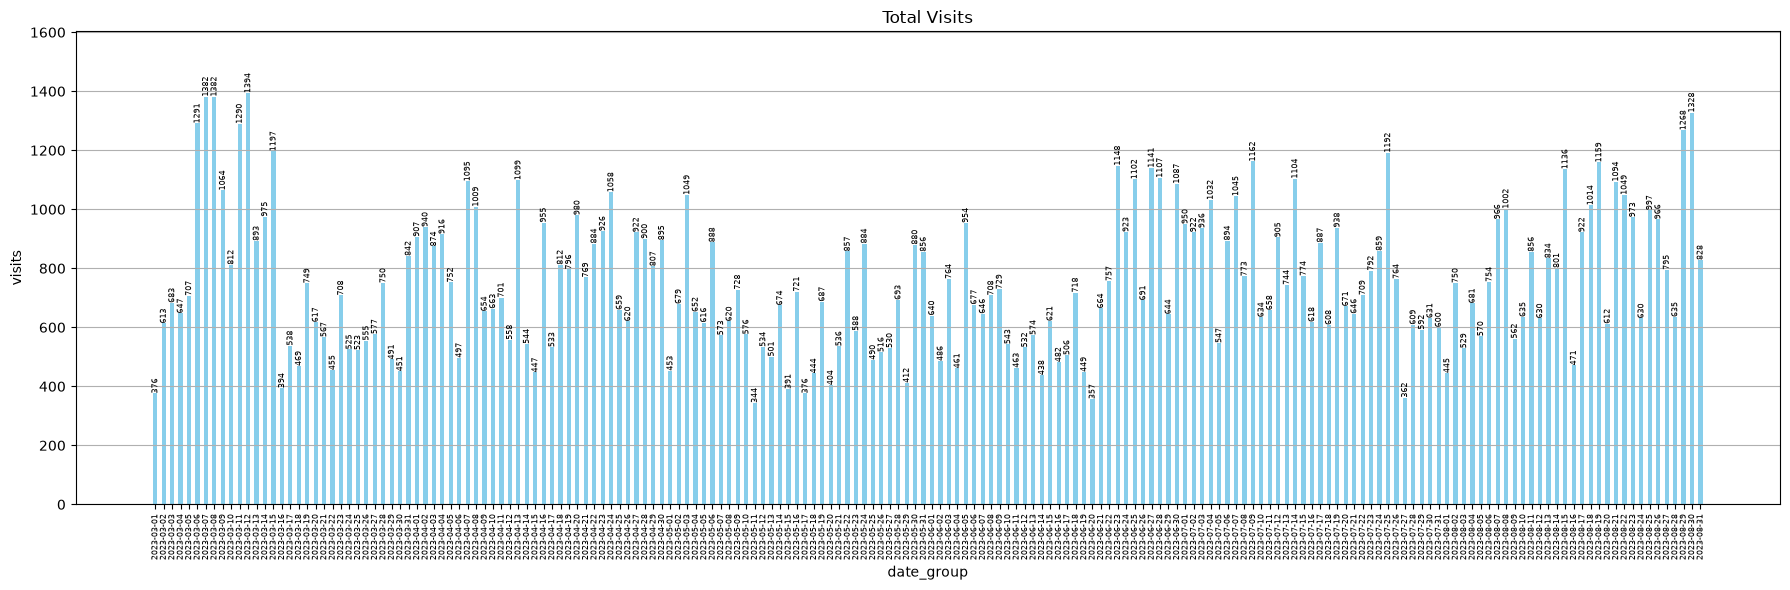

In [10]:
group_for_plot_visits = conv_ads_df.groupby(["date_group"], as_index=False)[
    "visits"
].sum()

plt.figure(figsize=(18, 6))

x_pos = range(len(group_for_plot_visits))

plt.bar(
    x_pos,
    group_for_plot_visits["visits"],
    width=0.5,
    color="skyblue",
)

# значения сверху — вертикально и мелким шрифтом
for x, y in zip(x_pos, group_for_plot_visits["visits"]):
    plt.text(x, y, str(int(y)), ha="center", va="bottom", rotation=90, fontsize=6)

plt.title("Total Visits")
plt.xlabel("date_group")
plt.ylabel("visits")
plt.grid(axis="y")

labels = group_for_plot_visits["date_group"].astype(str).tolist()
tick_idx = list(range(len(labels)))

ax = plt.gca()
ax.xaxis.set_major_locator(FixedLocator(tick_idx))
ax.xaxis.set_major_formatter(FixedFormatter(labels))
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=6, ha="center")

plt.ylim(0, group_for_plot_visits["visits"].max() * 1.15)

plt.tight_layout()
plt.savefig("./charts/visits_total.png", dpi=150)
plt.show()

Итоговые визиты с разбивкой по платформам: web, android, ios

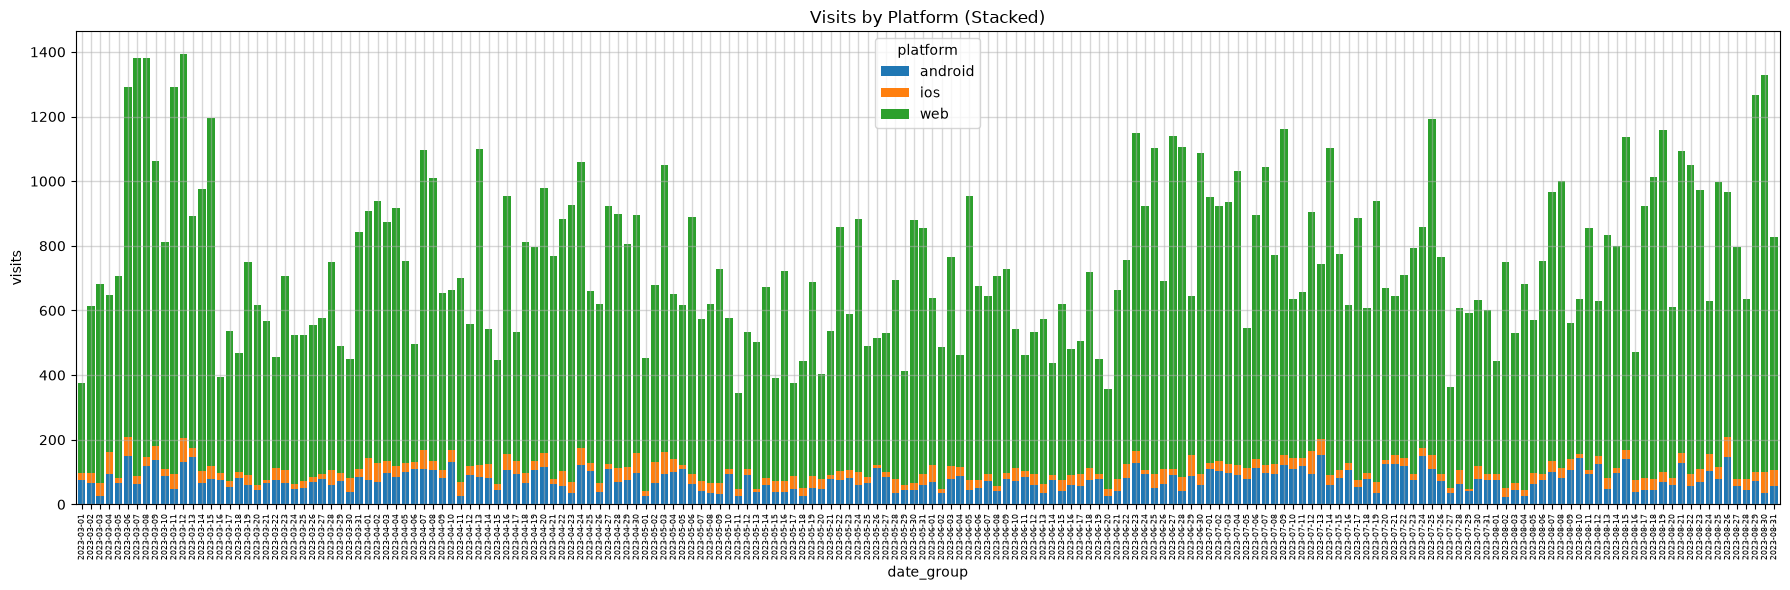

In [11]:
visits_by_platform = (
    df_result.groupby(["date_group", "platform"])["visits"].sum().unstack(fill_value=0)
)

# width=0.8 — одинаковая ширина всех столбцов
ax = visits_by_platform.plot(
    kind="bar",
    stacked=True,
    figsize=(18, 6),   # шире, чтобы дневные метки уместились
    width=0.8,
)

plt.title("Visits by Platform (Stacked)")
plt.xlabel("date_group")
plt.ylabel("visits")
plt.grid(alpha=0.5, linewidth=1.0)

# --- показываем ВСЕ даты (каждый день) ---
labels = visits_by_platform.index.astype(str).tolist()
tick_idx = list(range(len(labels)))

ax.xaxis.set_major_locator(FixedLocator(tick_idx))
ax.xaxis.set_major_formatter(FixedFormatter(labels))
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=6, ha="center")

plt.tight_layout()
plt.savefig("./charts/visits_by_platform.png", dpi=150)
plt.show()

Итоговые регистрации

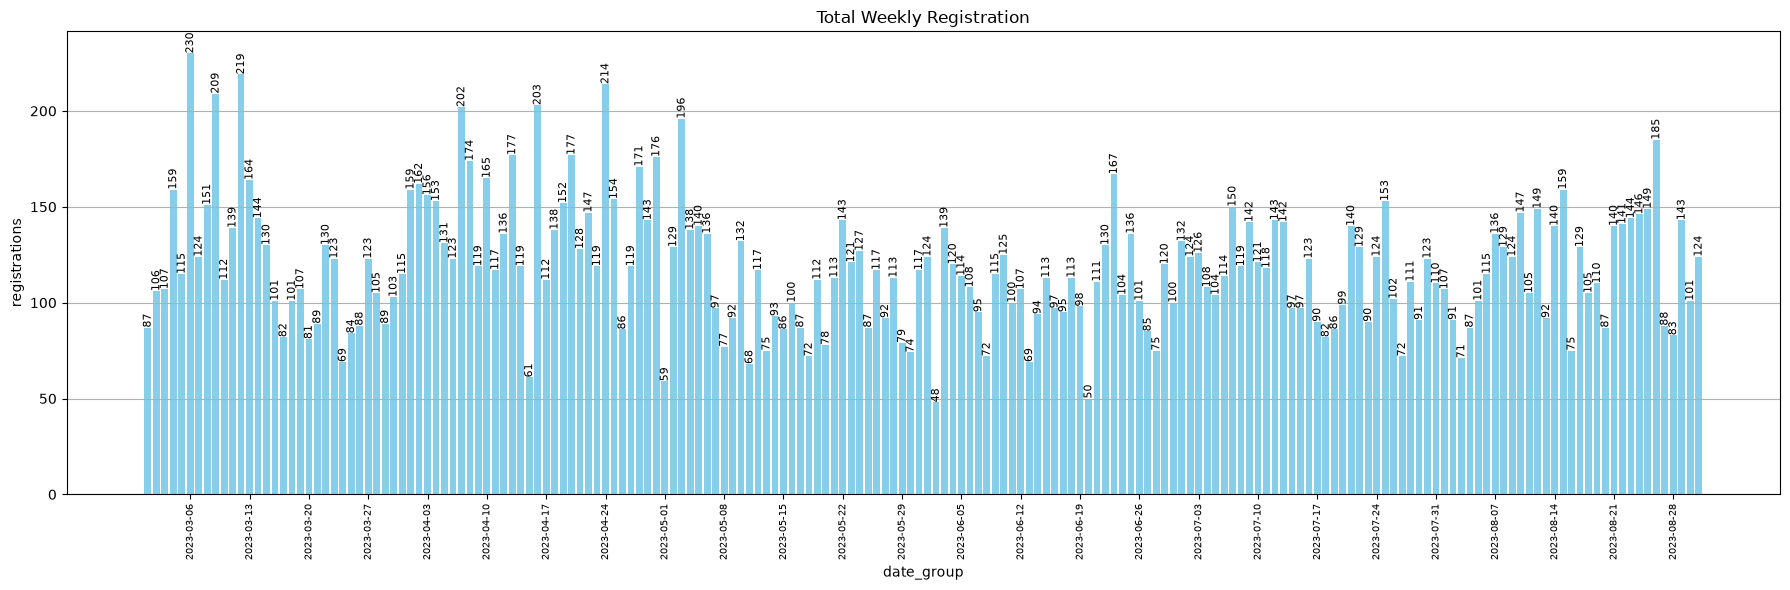

In [12]:
group_for_plot_regs = conv_ads_df.groupby(["date_group"], as_index=False)[
    "registrations"
].sum()

plt.figure(figsize=(18, 6))

x_pos = range(len(group_for_plot_regs))

plt.bar(
    x_pos,
    group_for_plot_regs["registrations"],
    width=0.8,
    color="skyblue",
)

# подписи над столбцами — вертикально
for x, y in zip(x_pos, group_for_plot_regs["registrations"]):
    plt.text(x, y, str(int(y)), ha="center", va="bottom", rotation=90, fontsize=8)

plt.title("Total Weekly Registration")
plt.xlabel("date_group")
plt.ylabel("registrations")
plt.grid(axis="y")

labels = group_for_plot_regs["date_group"].astype(str).tolist()

try:
    dates = pd.to_datetime(labels)
    week_idx = [i for i, d in enumerate(dates) if d.weekday() == 0]
    if not week_idx:
        raise ValueError
    tick_labels = [dates[i].strftime("%Y-%m-%d") for i in week_idx]
except Exception:
    week_idx = list(range(len(labels)))
    tick_labels = labels

ax = plt.gca()
ax.xaxis.set_major_locator(FixedLocator(week_idx))
ax.xaxis.set_major_formatter(FixedFormatter(tick_labels))
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=7, ha="center")

plt.tight_layout()
plt.savefig("./charts/registrations_total.png", dpi=150)
plt.show()

Итоговые регистрации с разбивкой по платформе: web, android, ios

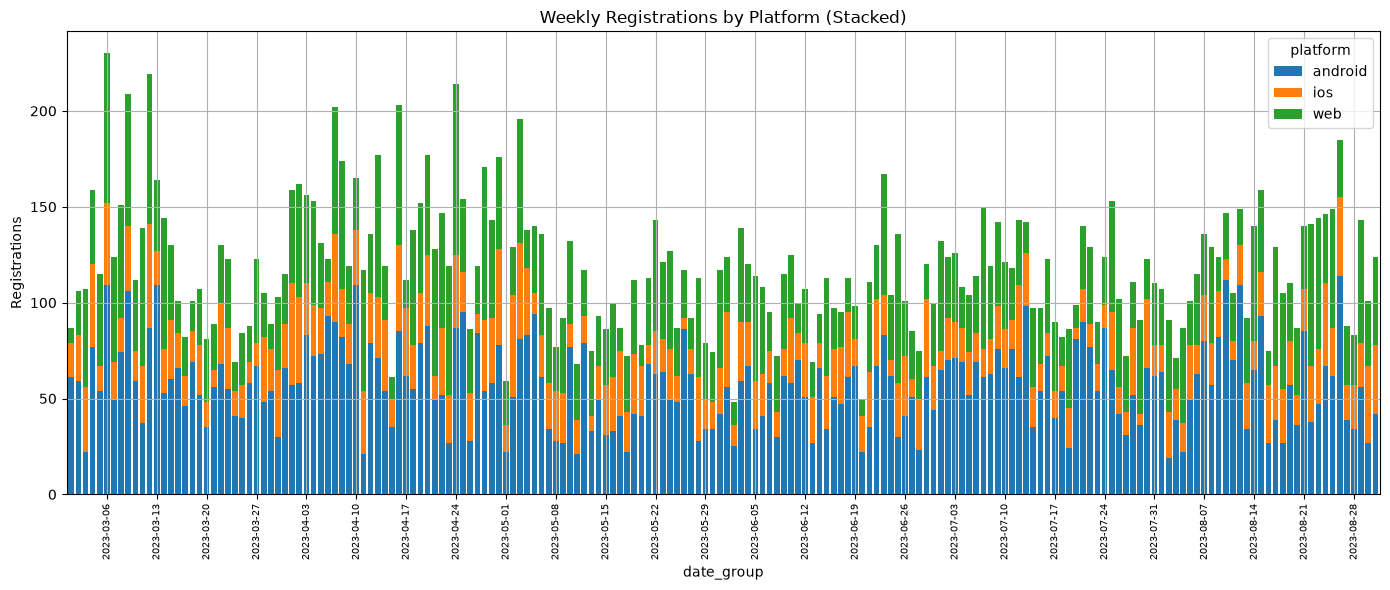

In [13]:
regs_by_platform = (
    df_result.groupby(["date_group", "platform"])["registrations"]
    .sum()
    .unstack(fill_value=0)
)

# --- фиксированная ширина столбцов ---
ax = regs_by_platform.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6),
    width=0.8,          # 0.8 — «стандартная» ширина; 1.0 — столбцы вплотную
)

plt.title("Weekly Registrations by Platform (Stacked)")
plt.xlabel("date_group")
plt.ylabel("Registrations")

# --- подписи только по неделям (по понедельникам) ---
x = list(range(len(regs_by_platform.index)))
labels = pd.to_datetime(regs_by_platform.index)

# индексы, где дата — понедельник (начало недели)
week_idx = [i for i, d in enumerate(labels) if d.weekday() == 0]

# если понедельников нет (данные не по дням) — берём первую метку каждой недели
if not week_idx:
    seen = set()
    week_idx = []
    for i, d in enumerate(labels):
        key = d.isocalendar()[:2]  # (год, номер недели)
        if key not in seen:
            seen.add(key)
            week_idx.append(i)

ax.xaxis.set_major_locator(FixedLocator(week_idx))
ax.xaxis.set_major_formatter(
    FixedFormatter([labels[i].strftime("%Y-%m-%d") for i in week_idx])
)
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=7, ha="center")

plt.grid()
plt.tight_layout()
plt.savefig("./charts/registrations_by_platform.png", dpi=150)
plt.show()

Подготовка данных для графика

In [14]:
agg_visits_for_plot = (
    visits_df.groupby(["date_group"]).size().reset_index(name="visits")
)
agg_regs_for_plot = (
    reg_df.groupby(["date_group"]).size().reset_index(name="registrations")
)
df_result_for_plot = pd.merge(
    agg_visits_for_plot, agg_regs_for_plot, on=["date_group"], how="outer"
).fillna(0)
df_result_for_plot["conversion"] = (
    (df_result_for_plot["registrations"] / df_result_for_plot["visits"]) * 100
).round(0)
df_result_for_plot = df_result_for_plot.sort_values("date_group").reset_index(drop=True)

Средняя конверсия

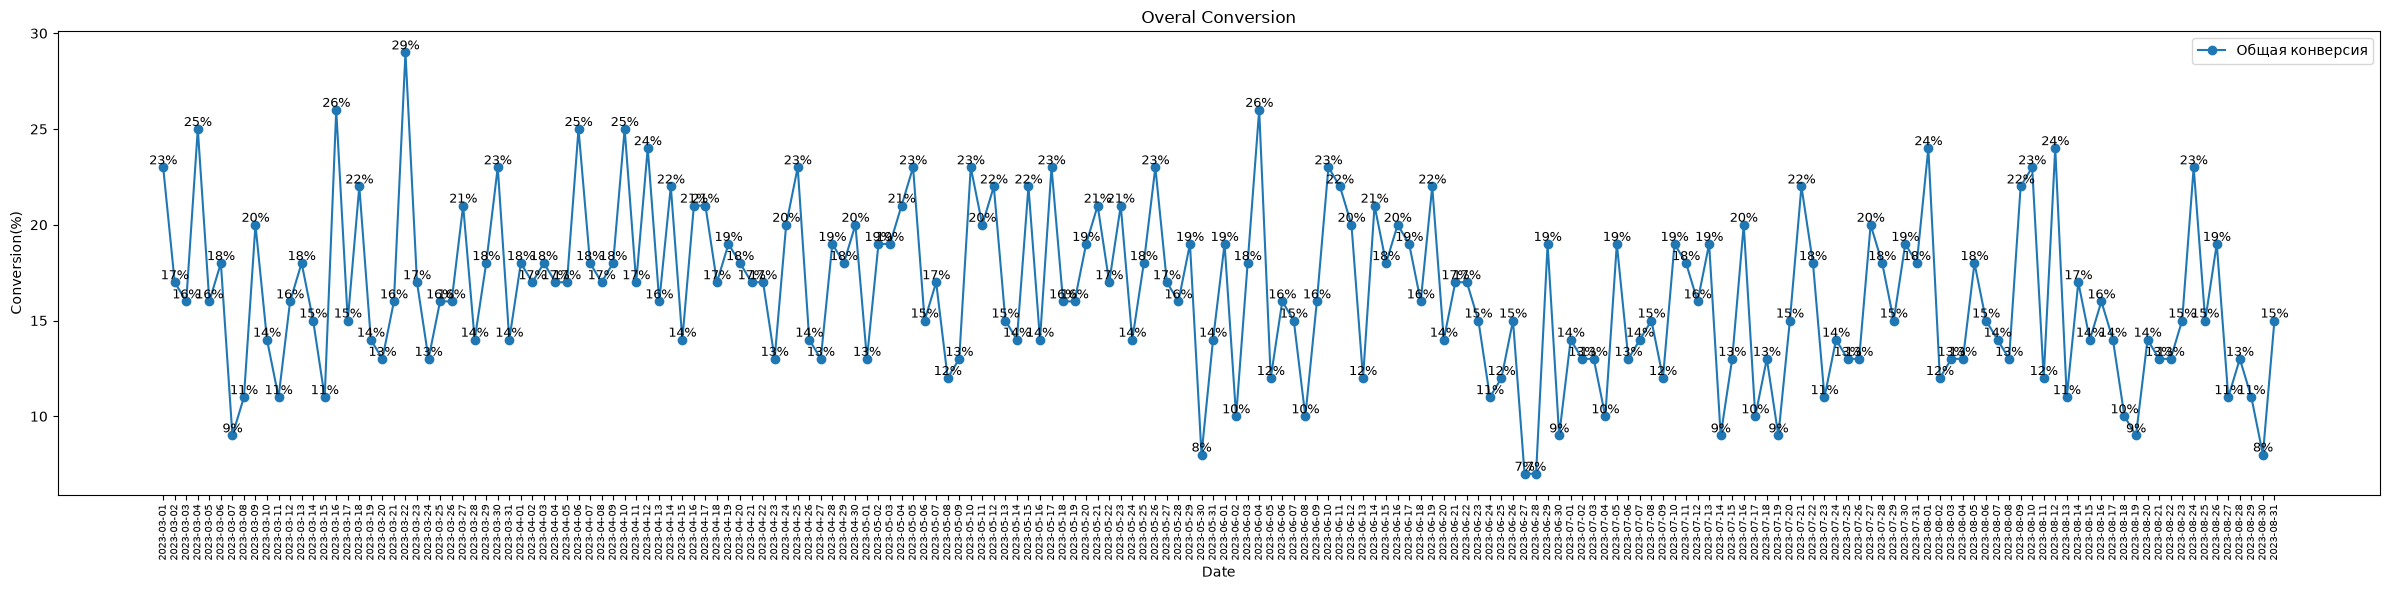

In [15]:
plt.figure(figsize=(24, 6))
plt.plot(
    df_result_for_plot["date_group"],
    df_result_for_plot["conversion"],
    marker="o",
    label="Общая конверсия",
)
for x, y in zip(df_result_for_plot["date_group"], df_result_for_plot["conversion"]):
    plt.text(x, y, f"{int(y)}%", ha="center", va="bottom", fontsize=9)
plt.legend()
plt.title("Overal Conversion")
plt.xlabel("Date")
plt.ylabel("Conversion(%)")
plt.xticks(
    df_result_for_plot["date_group"],
    rotation=90,
    fontsize=7,
    ha="center",
)
plt.tight_layout()
plt.savefig("./charts/overal_conversion.png")
plt.show()

Конверсия по каждой платформе

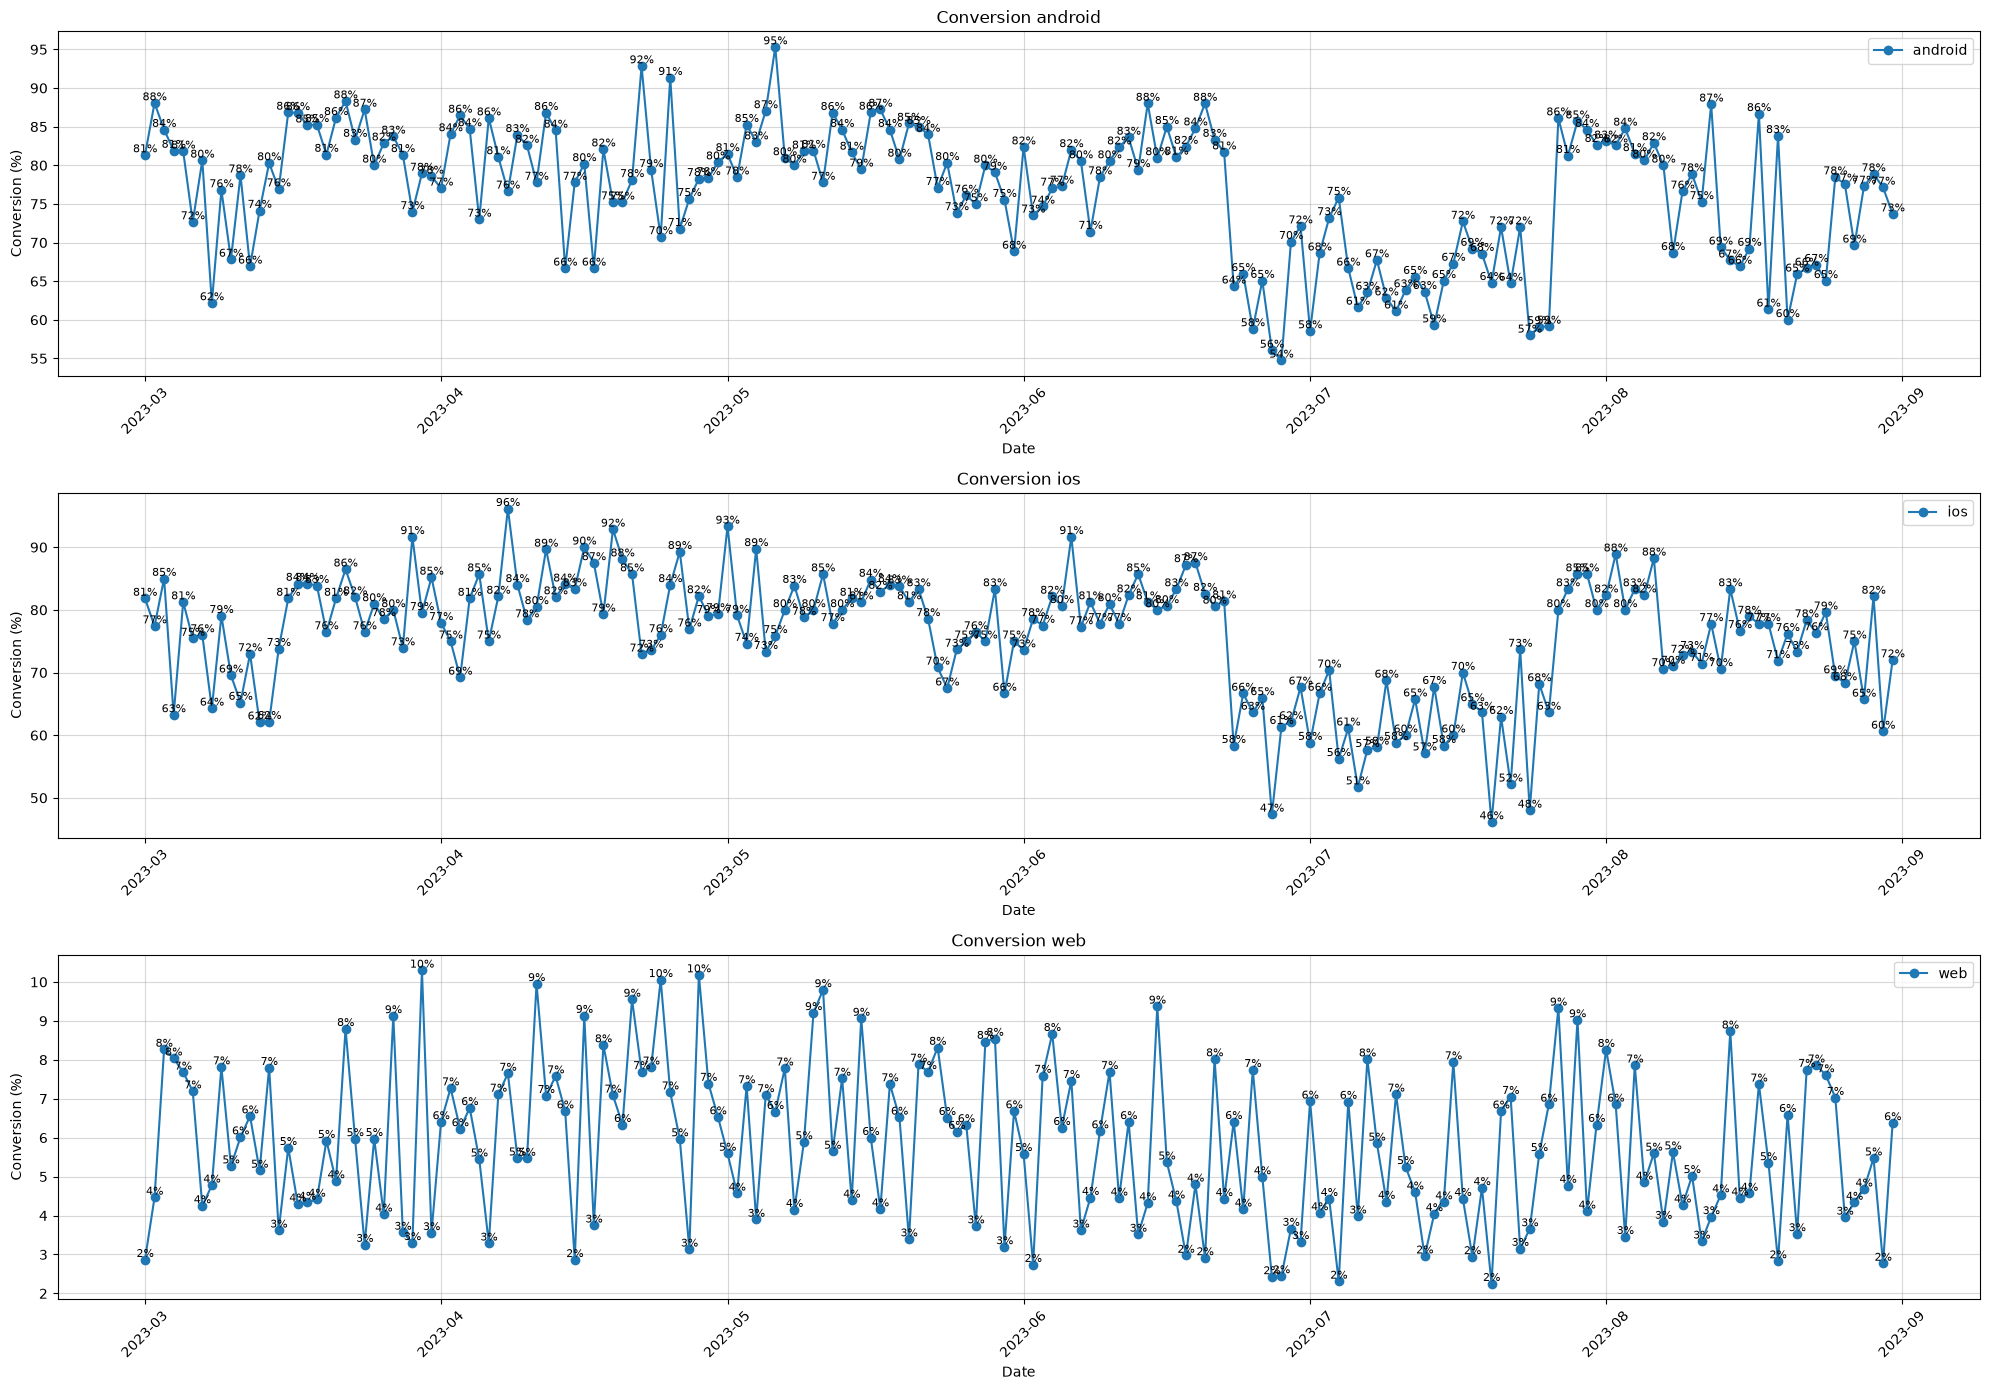

In [16]:
conv_by_platform = df_result.pivot(
    index="date_group", columns="platform", values="conversion"
).fillna(0)
plt.figure(figsize=(20, 14))
for i, col in enumerate(conv_by_platform.columns, start=1):
    plt.subplot(len(conv_by_platform.columns), 1, i)
    plt.plot(conv_by_platform.index, conv_by_platform[col], marker="o", label=col)
    for j in range(len(conv_by_platform)):
        x = conv_by_platform.index[j]
        y = conv_by_platform[col].iloc[j]
        plt.text(x, y, f"{int(y)}%", ha="center", va="bottom", fontsize=8)
    plt.title(f"Conversion {col}")
    plt.xlabel("Date")
    plt.ylabel("Conversion (%)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(alpha=0.5)
plt.tight_layout()
plt.savefig("./charts/conversion_by_platform_subplots.png")
plt.show()

Стоимости реклам

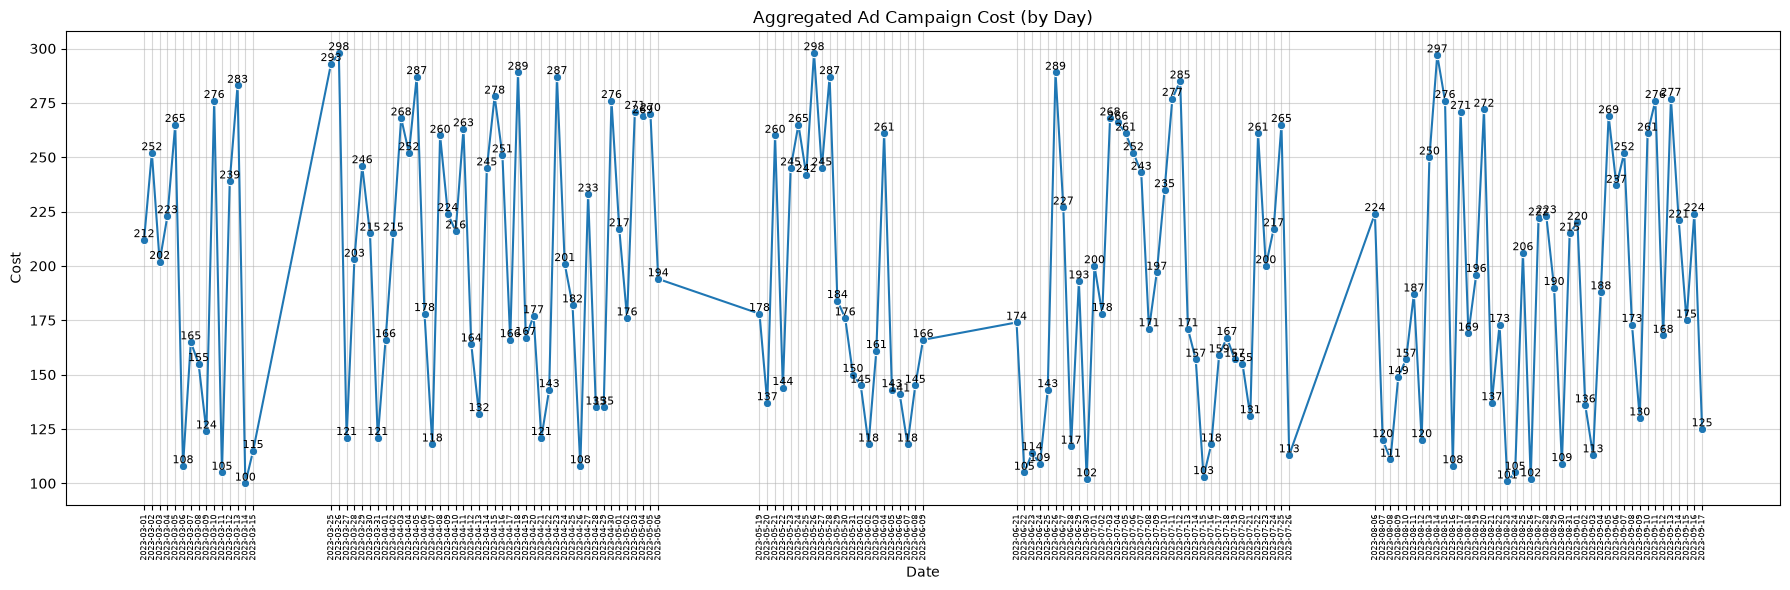

In [17]:
ads_by_date = ads_df.groupby("group_date", as_index=False)["cost"].sum()

plt.figure(figsize=(18, 6))
sns.lineplot(data=ads_by_date, x="group_date", y="cost", marker="o")

for x, y in zip(ads_by_date["group_date"], ads_by_date["cost"]):
    plt.text(x, y, str(int(y)), ha="center", va="bottom", fontsize=8)

plt.title("Aggregated Ad Campaign Cost (by Day)")
plt.xlabel("Date")
plt.ylabel("Cost")
plt.grid(alpha=0.5)

# --- даты вертикально и мелким шрифтом ---
ax = plt.gca()
ax.set_xticks(ads_by_date["group_date"])
ax.set_xticklabels(
    [d.strftime("%Y-%m-%d") for d in ads_by_date["group_date"]],
    rotation=90,
    fontsize=6,
    ha="center",
)

plt.tight_layout()
plt.savefig("./charts/ads_costs_seaborn.png", dpi=150)
plt.show()

подготовка данных для графика

In [18]:
visits_daily = conv_ads_df.groupby("date_group")["visits"].sum().reset_index()
regs_daily = conv_ads_df.groupby("date_group")["registrations"].sum().reset_index()
ads_by_day = ads_df.groupby(["group_date", "utm_campaign"])["cost"].sum().reset_index()

Визиты за весь период с цветовым выделением рекламной кампании. 
Регистрации за весь период с цветовым выделением рекламной кампании

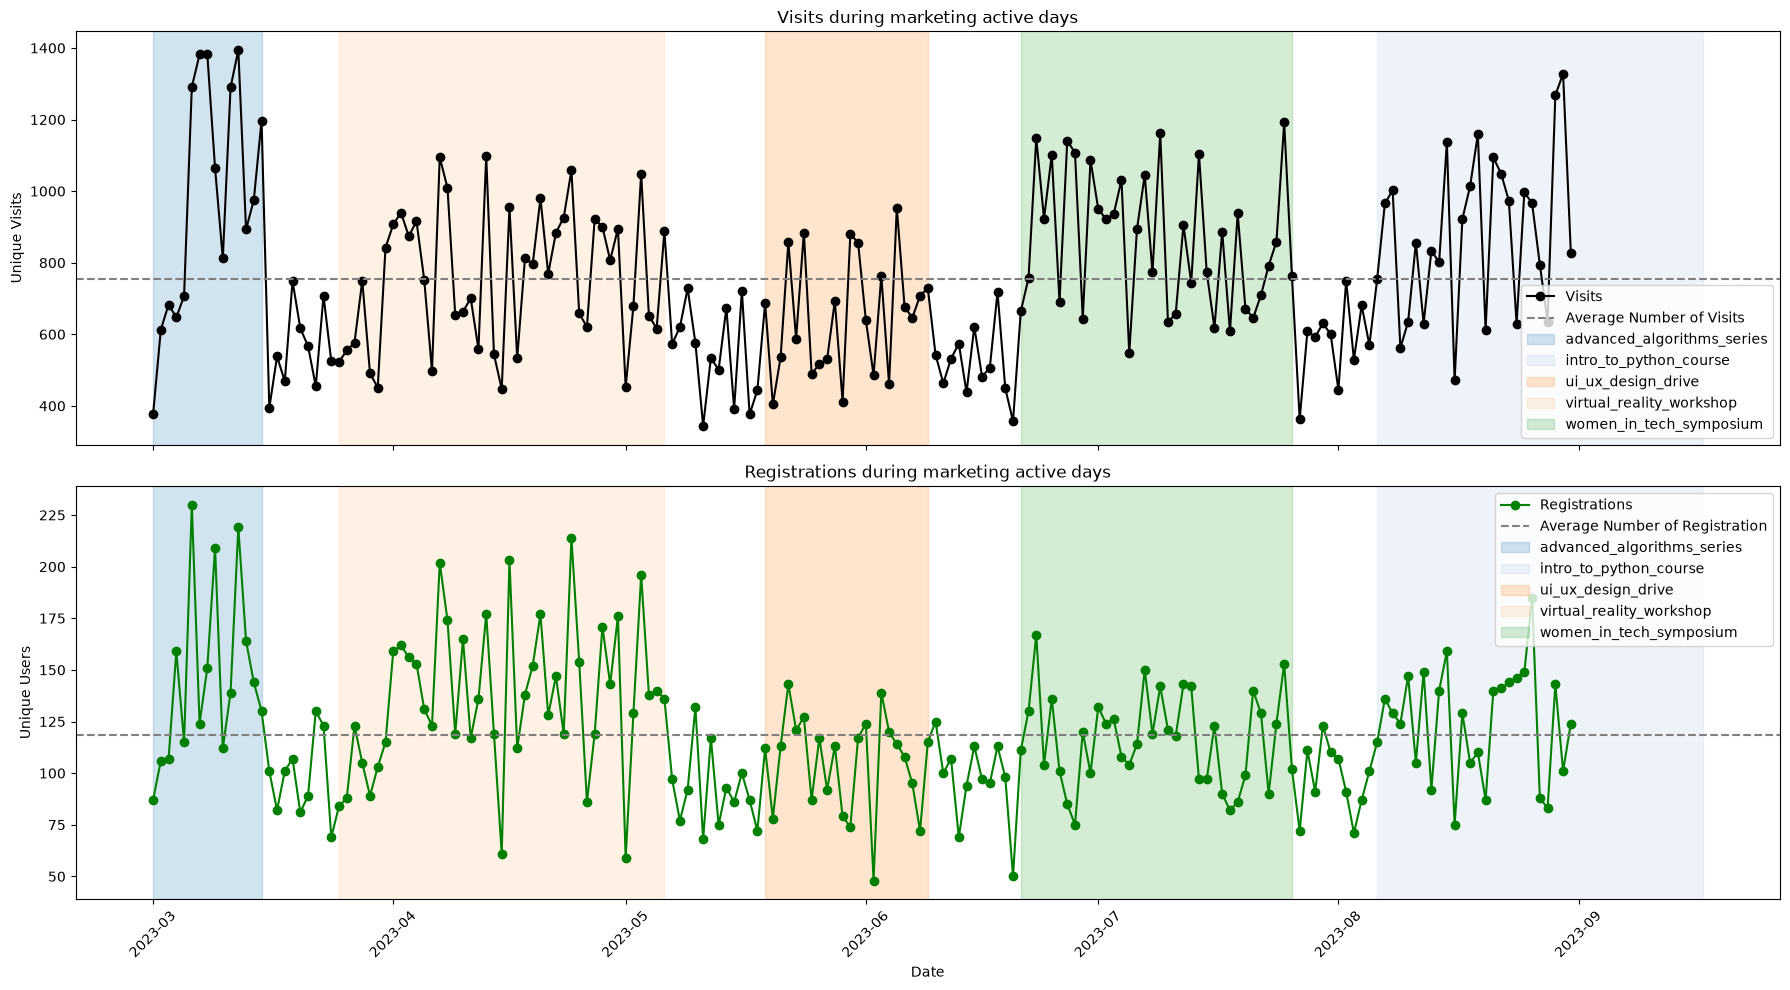

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
axes[0].plot(
    visits_daily["date_group"],
    visits_daily["visits"],
    marker="o",
    color="black",
    label="Visits",
)
avg_visits = visits_daily["visits"].mean()
axes[0].axhline(
    avg_visits, linestyle="--", color="gray", label="Average Number of Visits"
)
colors = plt.cm.tab20.colors
for i, (campaign, group) in enumerate(ads_by_day.groupby("utm_campaign")):
    start = group["group_date"].min()
    end = group["group_date"].max()
    axes[0].axvspan(
        start, end, alpha=0.2, color=colors[i % len(colors)], label=campaign
    )
axes[0].set_title("Visits during marketing active days")
axes[0].set_ylabel("Unique Visits")
axes[0].legend()
axes[1].plot(
    regs_daily["date_group"],
    regs_daily["registrations"],
    marker="o",
    color="green",
    label="Registrations",
)
avg_regs = regs_daily["registrations"].mean()
axes[1].axhline(
    avg_regs, linestyle="--", color="gray", label="Average Number of Registration"
)
for i, (campaign, group) in enumerate(ads_by_day.groupby("utm_campaign")):
    start = group["group_date"].min()
    end = group["group_date"].max()
    axes[1].axvspan(
        start, end, alpha=0.2, color=colors[i % len(colors)], label=campaign
    )
axes[1].set_title("Registrations during marketing active days")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Unique Users")
axes[1].legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("./charts/visits_regs_with_ads.png")
plt.show()